In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from trees.regression.gradient_boost import GradientBoost

# Load the diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape:  {X_test.shape}")

Training data shape: (353, 10)
Testing data shape:  (89, 10)


In [2]:
# Set matching hyperparameters
n_estimators = 100
max_depth = 3
min_samples_split = 2
min_samples_leaf = 1
learning_rate = 0.1

print("Training Custom Gradient Boosting...")
custom_gbm = GradientBoost(
    n_estimators=n_estimators,
    learning_rate=learning_rate,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf
)
# Note: Ensure your GradientBoost class uses learning_rate=0.1 internally or accepts it in __init__
custom_gbm.fit(X_train, y_train)

print("Training scikit-learn Gradient Boosting...")
sklearn_gbm = GradientBoostingRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    learning_rate=learning_rate,
    random_state=42
)
sklearn_gbm.fit(X_train, y_train)

print("Both models trained successfully!")

Training Custom Gradient Boosting...
Training scikit-learn Gradient Boosting...
Both models trained successfully!


In [3]:
# Generate predictions
y_pred_custom = custom_gbm.predict(X_test)
y_pred_sklearn = sklearn_gbm.predict(X_test)

# Calculate metrics
custom_mse = mean_squared_error(y_test, y_pred_custom)
sklearn_mse = mean_squared_error(y_test, y_pred_sklearn)

custom_r2 = r2_score(y_test, y_pred_custom)
sklearn_r2 = r2_score(y_test, y_pred_sklearn)

print("--- Mean Squared Error ---")
print(f"Custom GBM:  {custom_mse:.2f}")
print(f"Sklearn GBM: {sklearn_mse:.2f}")

print("\n--- R-Squared (Higher is better) ---")
print(f"Custom GBM:  {custom_r2:.4f}")
print(f"Sklearn GBM: {sklearn_r2:.4f}")

--- Mean Squared Error ---
Custom GBM:  2916.53
Sklearn GBM: 2887.23

--- R-Squared (Higher is better) ---
Custom GBM:  0.4495
Sklearn GBM: 0.4550


In [4]:
# Optional: Peek at the first tree's logic
print("\nFirst Tree Structure:")
custom_gbm.estimators[0].print_tree(feature_names=feature_names)


First Tree Structure:
Regression Tree Structure:
[bmi < 0.0051]
├── [s5 < 0.0062]
│   ├── [s5 < -0.0433]
│   │   ├── Leaf: value = -72.8590
│   │   └── Leaf: value = -43.8142
│   └── [s4 < 0.0897]
│       ├── Leaf: value = 5.8375
│       └── Leaf: value = 102.5968
└── [bmi < 0.0730]
    ├── [s6 < 0.0341]
    │   ├── Leaf: value = 22.0635
    │   └── Leaf: value = 76.7786
    └── [s2 < 0.0225]
        ├── Leaf: value = 137.4857
        └── Leaf: value = 72.0135


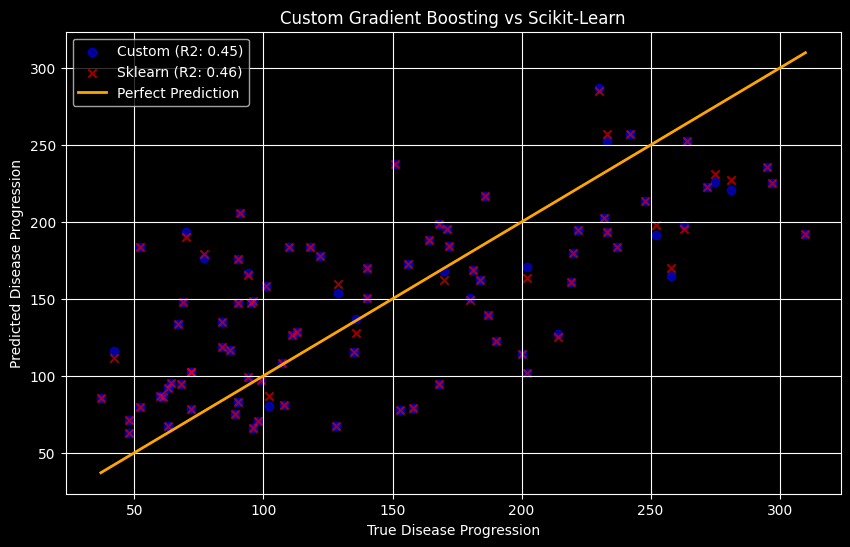

In [7]:
plt.figure(figsize=(10, 6))

# Plot True vs Predicted for both models
plt.scatter(y_test, y_pred_custom, alpha=0.6, label=f"Custom (R2: {custom_r2:.2f})", color="blue")
plt.scatter(y_test, y_pred_sklearn, alpha=0.6, label=f"Sklearn (R2: {sklearn_r2:.2f})", color="red", marker="x")

# Plot the perfect prediction diagonal
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], lw=2, label="Perfect Prediction", color="orange")

plt.xlabel("True Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Custom Gradient Boosting vs Scikit-Learn")
plt.legend()
plt.grid(True)
plt.show()